In [1]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '69716438e2191b6ccb383827', 'name': 'hshshsuuu', 'fullname': 'lee', 'isPro': False, 'avatarUrl': '/avatars/98d4b03694d0b42358e66feb6049edad.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'independentstudy', 'role': 'fineGrained', 'createdAt': '2026-03-16T13:33:53.173Z', 'fineGrained': {'canReadGatedRepos': True, 'global': [], 'scoped': [{'entity': {'_id': '69716438e2191b6ccb383827', 'type': 'user', 'name': 'hshshsuuu'}, 'permissions': ['repo.content.read', 'repo.access.read', 'repo.write']}]}}}}


In [ ]:
from huggingface_hub import login
token=''
login(token)

In [3]:
from datasets import load_dataset

data=load_dataset('zh-plus/tiny-imagenet')

In [4]:
data

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

60


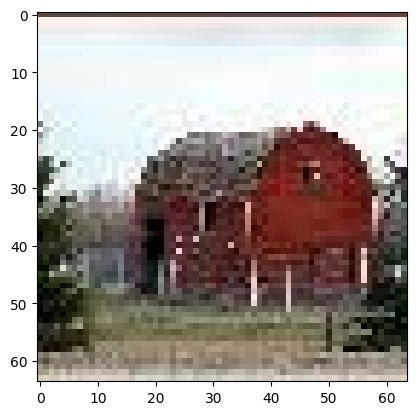

In [5]:
import matplotlib.pyplot as plt

im=data['train']['image'][30495]

plt.imshow(im)
print(data['train']['label'][30495])


In [6]:
from src.data import setdata

train=setdata(data['train'])
test=setdata(data['valid'])


In [7]:
x,y=train[0]
print(y)

0


In [8]:
from torch.utils.data import DataLoader

train_loader=DataLoader(train,batch_size=128,pin_memory=True,num_workers=4,shuffle=True)
test_loader=DataLoader(test,batch_size=128,pin_memory=True,num_workers=4,shuffle=True)

In [9]:
from transformers import AutoModel

model = AutoModel.from_pretrained(
    "facebook/dinov3-vits16plus-pretrain-lvd1689m"
)

print(model)

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

DINOv3ViTModel(
  (embeddings): DINOv3ViTEmbeddings(
    (patch_embeddings): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (rope_embeddings): DINOv3ViTRopePositionEmbedding()
  (layer): ModuleList(
    (0-11): 12 x DINOv3ViTLayer(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attention): DINOv3ViTAttention(
        (k_proj): Linear(in_features=384, out_features=384, bias=False)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (o_proj): Linear(in_features=384, out_features=384, bias=True)
      )
      (layer_scale1): DINOv3ViTLayerScale()
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): DINOv3ViTGatedMLP(
        (gate_proj): Linear(in_features=384, out_features=1536, bias=True)
        (up_proj): Linear(in_features=384, out_features=1536, bias=True)
        (down_proj): Linear(in_

In [10]:
for p in model.parameters():
    p.requires_grad=True

In [11]:
from src.model import dinosplus_classfier

vit=dinosplus_classfier(model,200)


In [12]:
import torch.optim as optim
import torch.nn as nn
import torch
optimizer=optim.Adam(vit.parameters(),lr=0.0001)
criterion=nn.CrossEntropyLoss()
scaler=torch.amp.GradScaler()


In [13]:
import torch

torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(False)

In [14]:
print(torch.cuda.is_available())
device='cuda' if torch.cuda.is_available() else 'cpu'


True


In [15]:
from src.training import train 
train(vit,train_loader,test_loader,50,criterion,scaler,device,optimizer,'full fine tuning vit dino v3 splus','/home/hyuksu/deep-learning-study/outputs/best dino v3 splus.pth')

2026/03/17 23:16:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/17 23:16:12 INFO mlflow.store.db.utils: Updating database tables
2026/03/17 23:16:13 INFO mlflow.tracking.fluent: Experiment with name 'full fine tuning vit dino v3 splus' does not exist. Creating a new experiment.


  0%|          | 0/50 [00:00<?, ?it/s]

Test Loss=0.8487, Test Accuracy=0.7838
Epoch 0 | Train Acc=0.6284 | Train Loss=1.9257
Test Loss=0.6862, Test Accuracy=0.8194
Epoch 1 | Train Acc=0.8618 | Train Loss=0.5256
Test Loss=0.6876, Test Accuracy=0.8270
Epoch 2 | Train Acc=0.9287 | Train Loss=0.2661
Test Loss=0.7586, Test Accuracy=0.8174
Epoch 3 | Train Acc=0.9602 | Train Loss=0.1444
Test Loss=0.7719, Test Accuracy=0.8213
Epoch 4 | Train Acc=0.9720 | Train Loss=0.1031
Test Loss=0.8271, Test Accuracy=0.8206
Epoch 5 | Train Acc=0.9823 | Train Loss=0.0667
Test Loss=0.8460, Test Accuracy=0.8265
Epoch 6 | Train Acc=0.9810 | Train Loss=0.0674
Test Loss=0.8923, Test Accuracy=0.8182
Epoch 7 | Train Acc=0.9852 | Train Loss=0.0521
Test Loss=0.9133, Test Accuracy=0.8158
Epoch 8 | Train Acc=0.9848 | Train Loss=0.0528
Test Loss=0.9106, Test Accuracy=0.8211
Epoch 9 | Train Acc=0.9874 | Train Loss=0.0435
Test Loss=0.9509, Test Accuracy=0.8193
Epoch 10 | Train Acc=0.9886 | Train Loss=0.0368
Test Loss=0.9656, Test Accuracy=0.8170
Epoch 11 | Tra

2026/03/18 00:18:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 00:18:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


최고 성능 모델이 MLflow에 저장되었습니다.


In [16]:
from transformers import AutoModel
from src.model import dinosplus_classfier
import torch.optim as optim
import torch
bdino=AutoModel.from_pretrained('facebook/dinov3-vitb16-pretrain-lvd1689m')

for i in bdino.parameters():
    i.required_grad=True
    
model2=dinosplus_classfier(bdino,200)
boptimizer=optim.Adam(model2.parameters(),lr=0.0001)
criterion2=torch.nn.CrossEntropyLoss()




Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [17]:
from src.training import train 
train(model2,train_loader,test_loader,50,criterion2,scaler,device,boptimizer,'full fine tuning vit dino v3 b','/home/hyuksu/deep-learning-study/outputs/best dino v3b.pth')

2026/03/18 00:18:49 INFO mlflow.tracking.fluent: Experiment with name 'full fine tuning vit dino v3 b' does not exist. Creating a new experiment.


  0%|          | 0/50 [00:00<?, ?it/s]

Test Loss=0.5793, Test Accuracy=0.8529
Epoch 0 | Train Acc=0.7306 | Train Loss=1.3554
Test Loss=0.5532, Test Accuracy=0.8561
Epoch 1 | Train Acc=0.9043 | Train Loss=0.3580
Test Loss=0.6259, Test Accuracy=0.8473
Epoch 2 | Train Acc=0.9492 | Train Loss=0.1813
Test Loss=0.6366, Test Accuracy=0.8500
Epoch 3 | Train Acc=0.9656 | Train Loss=0.1214
Test Loss=0.7002, Test Accuracy=0.8399
Epoch 4 | Train Acc=0.9711 | Train Loss=0.0994
Test Loss=0.6966, Test Accuracy=0.8446
Epoch 5 | Train Acc=0.9761 | Train Loss=0.0829
Test Loss=0.7580, Test Accuracy=0.8386
Epoch 6 | Train Acc=0.9839 | Train Loss=0.0550
Test Loss=0.7557, Test Accuracy=0.8393
Epoch 7 | Train Acc=0.9805 | Train Loss=0.0656
Test Loss=0.8021, Test Accuracy=0.8385
Epoch 8 | Train Acc=0.9847 | Train Loss=0.0537
Test Loss=0.8428, Test Accuracy=0.8265
Epoch 9 | Train Acc=0.9846 | Train Loss=0.0529
Test Loss=0.7951, Test Accuracy=0.8432
Epoch 10 | Train Acc=0.9864 | Train Loss=0.0472
Test Loss=0.7886, Test Accuracy=0.8431
Epoch 11 | Tra

2026/03/18 02:14:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 02:14:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


최고 성능 모델이 MLflow에 저장되었습니다.
